In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
file_name = 'Marketing_Pack.xlsx'

In [ ]:
excel_file = pd.read_excel(file_name, sheet_name=None)

# Automatically create a dataframe variable for every sheet name
for sheet_name, df in excel_file.items():
    globals()[f"{sheet_name}"] = df

### Customer-level view

#### Trajectory Features

In [ ]:
def calculate_kpi_trajectory(
    data,
    kpi_name="KPI"
):
    df = data.copy()

    month_cols = []

    for col in df.columns:
        try:
            pd.to_datetime(col, format="%Y-%m-%d")
            month_cols.append(col)
        except (ValueError, TypeError):
            pass

    month_cols = sorted(
        month_cols,
        key=lambda x: pd.to_datetime(x)
    )

    df[month_cols] = df[month_cols].apply(
        pd.to_numeric,
        errors="coerce"
    )

    def growth_pct(start, end):
        if pd.isna(start) or pd.isna(end) or start == 0:
            return np.nan

        return ((end - start) / abs(start)) * 100

    def direction(x, threshold=3):
        if pd.isna(x):
            return "Unknown"
        elif x > threshold:
            return "Growing"
        elif x < -threshold:
            return "Declining"
        else:
            return "Stable"

    def calculate_trajectory(row):
        values = row[month_cols].values.astype(float)
        values = values[~np.isnan(values)]

        if len(values) < 6:
            return pd.Series({
                f"Recent_3M_{kpi_name}_Growth_Pct": np.nan,
                f"Recent_3M_{kpi_name}_Direction": "Unknown",
                f"Recent_12M_{kpi_name}_Growth_Pct": np.nan,
                f"Recent_12M_{kpi_name}_Direction": "Unknown",
                f"Overall_{kpi_name}_Growth_Pct": np.nan,
                f"Overall_{kpi_name}_Direction": "Unknown",
                f"{kpi_name}_Trajectory": "Unknown"
            })

        n = len(values)

        recent_3m = growth_pct(
            values[-6:-3].mean(),
            values[-3:].mean()
        )

        recent_12m = np.nan

        if n >= 24:
            recent_12m = growth_pct(
                values[-24:-12].mean(),
                values[-12:].mean()
            )

        overall_growth = growth_pct(
            values[0],
            values[-1]
        )

        recent_3m_direction = direction(recent_3m)
        recent_12m_direction = direction(recent_12m)
        overall_direction = direction(overall_growth)

        if (
            recent_12m_direction == "Growing"
            and recent_3m_direction == "Growing"
        ):
            trajectory = "Consistent Growth"

        elif (
            recent_12m_direction == "Declining"
            and recent_3m_direction == "Declining"
        ):
            trajectory = "Consistent Decline"

        elif (
            recent_12m_direction == "Growing"
            and recent_3m_direction == "Declining"
        ):
            trajectory = "Growth to Decline"

        elif (
            recent_12m_direction == "Declining"
            and recent_3m_direction == "Growing"
        ):
            trajectory = "Decline to Growth"

        elif (
            recent_12m_direction == "Stable"
            and recent_3m_direction == "Growing"
        ):
            trajectory = "Stable to Growth"

        elif (
            recent_12m_direction == "Stable"
            and recent_3m_direction == "Declining"
        ):
            trajectory = "Stable to Decline"

        elif (
            recent_12m_direction == "Growing"
            and recent_3m_direction == "Stable"
        ):
            trajectory = "Growth to Stable"

        elif (
            recent_12m_direction == "Declining"
            and recent_3m_direction == "Stable"
        ):
            trajectory = "Decline to Stable"

        else:
            trajectory = "Stable / Mixed"

        return pd.Series({
            # f"Recent_3M_{kpi_name}_Growth_Pct": recent_3m,
            f"Recent_3M_{kpi_name}_Direction": recent_3m_direction,
            # f"Recent_12M_{kpi_name}_Growth_Pct": recent_12m,
            # f"Recent_12M_{kpi_name}_Direction": recent_12m_direction,
            # f"Overall_{kpi_name}_Growth_Pct": overall_growth,
            f"Overall_{kpi_name}_Direction": overall_direction,
            f"{kpi_name}_Trajectory": trajectory
        })

    trajectory_features = df.apply(
        calculate_trajectory,
        axis=1
    )

    result = pd.concat(
        [
            df.drop(columns=month_cols),
            trajectory_features
        ],
        axis=1
    )

    return result

#### Revenue

In [ ]:
Monthly_Customer_Revenue = Sales_Transactions.groupby(['Month','Customer_ID']).agg(Net_Revenue = ('Invoice_Value_INR_000','sum')).reset_index()
Customer_Revenue_Pivot = Monthly_Customer_Revenue.pivot(index='Customer_ID',columns='Month',values='Net_Revenue').reset_index()

In [ ]:
Customer_Revenue_Trajectory = calculate_kpi_trajectory(
    Customer_Revenue_Pivot,
    kpi_name="Revenue")
Customer_Revenue_Trajectory.sample()

,Customer_ID,Recent_3M_Revenue_Direction,Overall_Revenue_Direction,Revenue_Trajectory
736,MKT_C100736,Declining,Growing,Growth to Decline


#### Sales

In [ ]:
Monthly_Customer_Sales = Sales_Transactions.groupby(['Month','Customer_ID']).agg(Net_Sales = ('Quantity_MT','sum')).reset_index()
Customer_Sales_Pivot = Monthly_Customer_Sales.pivot(index='Customer_ID',columns='Month',values='Net_Sales').reset_index()

In [ ]:
Customer_Sales_Trajectory = calculate_kpi_trajectory(
    Customer_Revenue_Pivot,
    kpi_name="Net_Sales")
Customer_Sales_Trajectory.sample()

,Customer_ID,Recent_3M_Net_Sales_Direction,Overall_Net_Sales_Direction,Net_Sales_Trajectory
213,MKT_C100213,Declining,Declining,Consistent Decline


#### Add Sales and Revenue trajectory features to Customer Master Dataset

In [ ]:
Customer_Sales = Customer_Master[['Customer_ID','Industry_Segment','Customer_Type','Years_With_Company','Strategic_Account_Flag']].merge(Customer_Sales_Trajectory,on='Customer_ID',how='left')
Customer_Sales_Revenue = Customer_Sales.merge(Customer_Revenue_Trajectory,on='Customer_ID',how='left')
print(Customer_Sales_Revenue.shape)
Customer_Sales_Revenue.sample(5)

(850, 11)


,Customer_ID,Industry_Segment,Customer_Type,Years_With_Company,Strategic_Account_Flag,Recent_3M_Net_Sales_Direction,Overall_Net_Sales_Direction,Net_Sales_Trajectory,Recent_3M_Revenue_Direction,Overall_Revenue_Direction,Revenue_Trajectory
848,MKT_C100848,Engineering,Direct,9,1,Growing,Growing,Decline to Growth,Growing,Growing,Decline to Growth
72,MKT_C100072,Pharma,Export,10,0,Growing,Growing,Decline to Growth,Growing,Growing,Decline to Growth
202,MKT_C100202,Engineering,Export,13,0,Declining,Stable,Growth to Decline,Declining,Stable,Growth to Decline
225,MKT_C100225,Automotive,OEM,2,0,Declining,Growing,Growth to Decline,Declining,Growing,Growth to Decline
780,MKT_C100780,Engineering,Export,12,1,Growing,Growing,Consistent Growth,Growing,Growing,Consistent Growth


### Discount Summary

In [ ]:
Discount_Summary = Customer_Master[['Customer_ID','Industry_Segment','Strategic_Account_Flag']].merge(Sales_Transactions[['Customer_ID','Discount_Pct']],on=['Customer_ID']).groupby(['Industry_Segment','Strategic_Account_Flag']).agg(
    Min_Discount = ('Discount_Pct','min'),
    Max_Discount = ('Discount_Pct','max'),
    Mean_Discount = ('Discount_Pct','mean'),
    Median_Discount = ('Discount_Pct','median'),
    Common_Discount = ('Discount_Pct', lambda x: x.mode().iat[0] if not x.mode().empty else None)
).reset_index()
Discount_Summary


,Industry_Segment,Strategic_Account_Flag,Min_Discount,Max_Discount,Mean_Discount,Median_Discount,Common_Discount
0,Agrochemicals,0,0.00,23.22,5.478401,5.225,0.00
1,Agrochemicals,1,0.00,21.44,5.687880,5.295,2.38
2,Automotive,0,0.00,21.89,5.764045,5.310,0.00
3,Automotive,1,0.00,20.53,6.206933,5.520,4.21
4,Engineering,0,0.00,19.82,5.812627,5.360,0.00
5,Engineering,1,0.00,18.25,5.453592,5.100,3.15
6,Exports-Trader,0,0.00,19.38,5.723718,5.300,3.61
7,Exports-Trader,1,0.00,19.78,5.975814,5.330,5.25
8,FMCG,0,0.00,20.98,5.863294,5.400,5.10
9,FMCG,1,0.14,20.58,6.313671,5.690,4.66


### Quotation Summary

In [ ]:
df = Quotation_Data.copy()

df["Quote_Date"] = pd.to_datetime(df["Quote_Date"])

latest_date = df["Quote_Date"].max()
three_month_start = latest_date - pd.DateOffset(months=3)

df["Recent_3M"] = df["Quote_Date"] >= three_month_start

overall = (
    df.groupby("Customer_ID")
    .agg(
        Total_Quotes=("Quote_ID", "count"),
        Total_Won=("Quote_Status", lambda x: (x == "Won").sum()),
        Total_Lost=("Quote_Status", lambda x: (x == "Lost").sum()),
        Total_Pending=("Quote_Status", lambda x: (x == "Pending").sum()),
        Loss_Due_To_Price=(
            "Loss_Reason",
            lambda x: (x == "Price High").sum()
        )
    )
    .reset_index()
)

overall["Win_Ratio"] = (
    overall["Total_Won"] / overall["Total_Quotes"]
)

overall["Loss_Ratio"] = (
    overall["Total_Lost"] / overall["Total_Quotes"]
)

overall["Price_Loss_Ratio"] = np.where(
    overall["Total_Lost"] > 0,
    overall["Loss_Due_To_Price"] / overall["Total_Lost"],
    0
)

recent = (
    df[df["Recent_3M"]]
    .groupby("Customer_ID")
    .agg(
        Recent_3M_Quotes=("Quote_ID", "count"),
        Recent_3M_Won=("Quote_Status", lambda x: (x == "Won").sum()),
        Recent_3M_Lost=("Quote_Status", lambda x: (x == "Lost").sum()),
        Recent_3M_Pending=("Quote_Status", lambda x: (x == "Pending").sum()),
        Recent_3M_Loss_Due_To_Price=(
            "Loss_Reason",
            lambda x: (x == "Price High").sum()
        )
    )
    .reset_index()
)

recent["Recent_3M_Win_Ratio"] = np.where(
    recent["Recent_3M_Quotes"] > 0,
    recent["Recent_3M_Won"] / recent["Recent_3M_Quotes"],
    0
)

recent["Recent_3M_Loss_Ratio"] = np.where(
    recent["Recent_3M_Quotes"] > 0,
    recent["Recent_3M_Lost"] / recent["Recent_3M_Quotes"],
    0
)

recent["Recent_3M_Price_Loss_Ratio"] = np.where(
    recent["Recent_3M_Lost"] > 0,
    recent["Recent_3M_Loss_Due_To_Price"] / recent["Recent_3M_Lost"],
    0
)

Customer_Quotation_Features = (
    overall
    .merge(
        recent,
        on="Customer_ID",
        how="left"
    )
    .fillna(0)
)

Customer_Quotation_Features["Win_Ratio_Change"] = (
    Customer_Quotation_Features["Recent_3M_Win_Ratio"]
    - Customer_Quotation_Features["Win_Ratio"]
)

# Customer_Quotation_Features["Price_Loss_Ratio_Change"] = (
#     Customer_Quotation_Features["Recent_3M_Price_Loss_Ratio"]
#     - Customer_Quotation_Features["Price_Loss_Ratio"]
# )

Customer_Quotation_Summary = Customer_Quotation_Features[['Customer_ID','Total_Quotes','Win_Ratio','Recent_3M_Quotes','Recent_3M_Win_Ratio']]
print(Customer_Quotation_Summary.shape)
Customer_Quotation_Summary.sample()

(850, 5)


,Customer_ID,Total_Quotes,Win_Ratio,Recent_3M_Quotes,Recent_3M_Win_Ratio
674,MKT_C100674,21,0.52381,5.0,0.8


#### Add Quotation features to CSR table

In [ ]:
CSRQ = Customer_Sales_Revenue.merge(Customer_Quotation_Summary,on='Customer_ID',how='left')
print(CSRQ.shape)
CSRQ.sample()

(850, 15)


,Customer_ID,Industry_Segment,Customer_Type,Years_With_Company,Strategic_Account_Flag,Recent_3M_Net_Sales_Direction,Overall_Net_Sales_Direction,Net_Sales_Trajectory,Recent_3M_Revenue_Direction,Overall_Revenue_Direction,Revenue_Trajectory,Total_Quotes,Win_Ratio,Recent_3M_Quotes,Recent_3M_Win_Ratio
647,MKT_C100647,Automotive,Direct,15,0,Growing,Declining,Decline to Growth,Growing,Declining,Decline to Growth,10,0.4,0.0,0.0


### Complaints summary CSAT

In [ ]:
df = Customer_Complaints.copy()

df["Complaint_Date"] = pd.to_datetime(df["Complaint_Date"])

latest_date = df["Complaint_Date"].max()
three_month_start = latest_date - pd.DateOffset(months=3)

df["Complaint_Last_3M"] = (
    df["Complaint_Date"] >= three_month_start
)

df["Complaint_Category"] = (
    df["Complaint_Type"].astype(str)
    + " - "
    + df["Severity"].astype(str)
)

most_frequent_complaint = (
    df.groupby("Customer_ID")["Complaint_Category"]
    .agg(
        lambda x: x.mode().iloc[0]
        if not x.mode().empty
        else "Unknown"
    )
    .rename("Most_Frequent_Complaint")
)

customer_complaints = (
    df.groupby("Customer_ID")
    .agg(
        Total_Complaints=("Customer_ID", "size"),
        Median_Resolution_Days=("Resolution_Days", "median")
    )
)

recent_3m = (
    df[df["Complaint_Last_3M"]]
    .groupby("Customer_ID")
    .size()
    .rename("Recent_3M_Complaints")
)

Customer_Complaint_Features = (
    customer_complaints
    .join(recent_3m, how="left")
    .join(most_frequent_complaint, how="left")
    .reset_index()
)

Customer_Complaint_Features["Recent_3M_Complaints"] = (
    Customer_Complaint_Features["Recent_3M_Complaints"]
    .fillna(0)
    .astype(int)
)

Customer_Complaint_Features.sample()


,Customer_ID,Total_Complaints,Median_Resolution_Days,Recent_3M_Complaints,Most_Frequent_Complaint
471,MKT_C100474,3,7.0,0,Delivery - Critical


#### Add CSAT features

In [ ]:
CSRQ_CSAT = CSRQ.merge(Customer_Complaint_Features,on='Customer_ID',how='left')
print(CSRQ_CSAT.shape)
CSRQ_CSAT.sample()

(850, 19)


,Customer_ID,Industry_Segment,Customer_Type,Years_With_Company,Strategic_Account_Flag,Recent_3M_Net_Sales_Direction,Overall_Net_Sales_Direction,Net_Sales_Trajectory,Recent_3M_Revenue_Direction,Overall_Revenue_Direction,Revenue_Trajectory,Total_Quotes,Win_Ratio,Recent_3M_Quotes,Recent_3M_Win_Ratio,Total_Complaints,Median_Resolution_Days,Recent_3M_Complaints,Most_Frequent_Complaint
233,MKT_C100233,Paints & Coatings,Direct,6,0,Declining,Declining,Stable to Decline,Declining,Declining,Stable to Decline,14,0.357143,3.0,0.0,3.0,25.0,0.0,Delivery - Medium


### Payment Behavior Data

In [ ]:
df = Payment_Behaviour.copy()

Customer_Payment_Features = (
    df.groupby("Customer_ID")
    .agg(
        Total_Instances=("Invoice_ID", "count"),
        Invoices_Paid_On_or_Before_Due=(
            "Days_Past_Due",
            lambda x: (x <= 0).sum()
        ),
        Median_Days_Past_Due=(
            "Days_Past_Due",
            "median"
        )
    )
    .reset_index()
)

Customer_Payment_Features["On_Time_Payment_Ratio"] = (
    Customer_Payment_Features["Invoices_Paid_On_or_Before_Due"]
    / Customer_Payment_Features["Total_Instances"]
)

Customer_Payment_Features.sample()


,Customer_ID,Total_Instances,Invoices_Paid_On_or_Before_Due,Median_Days_Past_Due,On_Time_Payment_Ratio
122,MKT_C100122,35,13,5.0,0.371429


#### Add Payment Behavior features

In [ ]:
CSRQ_CSAT_PMT = CSRQ_CSAT.merge(Customer_Payment_Features,on='Customer_ID',how='left')
print(CSRQ_CSAT_PMT.shape)
CSRQ_CSAT_PMT.sample()

(850, 23)


,Customer_ID,Industry_Segment,Customer_Type,Years_With_Company,Strategic_Account_Flag,Recent_3M_Net_Sales_Direction,Overall_Net_Sales_Direction,Net_Sales_Trajectory,Recent_3M_Revenue_Direction,Overall_Revenue_Direction,...,Recent_3M_Quotes,Recent_3M_Win_Ratio,Total_Complaints,Median_Resolution_Days,Recent_3M_Complaints,Most_Frequent_Complaint,Total_Instances,Invoices_Paid_On_or_Before_Due,Median_Days_Past_Due,On_Time_Payment_Ratio
808,MKT_C100808,Pharma,Direct,1,0,Declining,Growing,Growth to Decline,Declining,Growing,...,1.0,0.0,7.0,22.0,0.0,Documentation - Low,71,22,8.0,0.309859


### Understanding Market Index

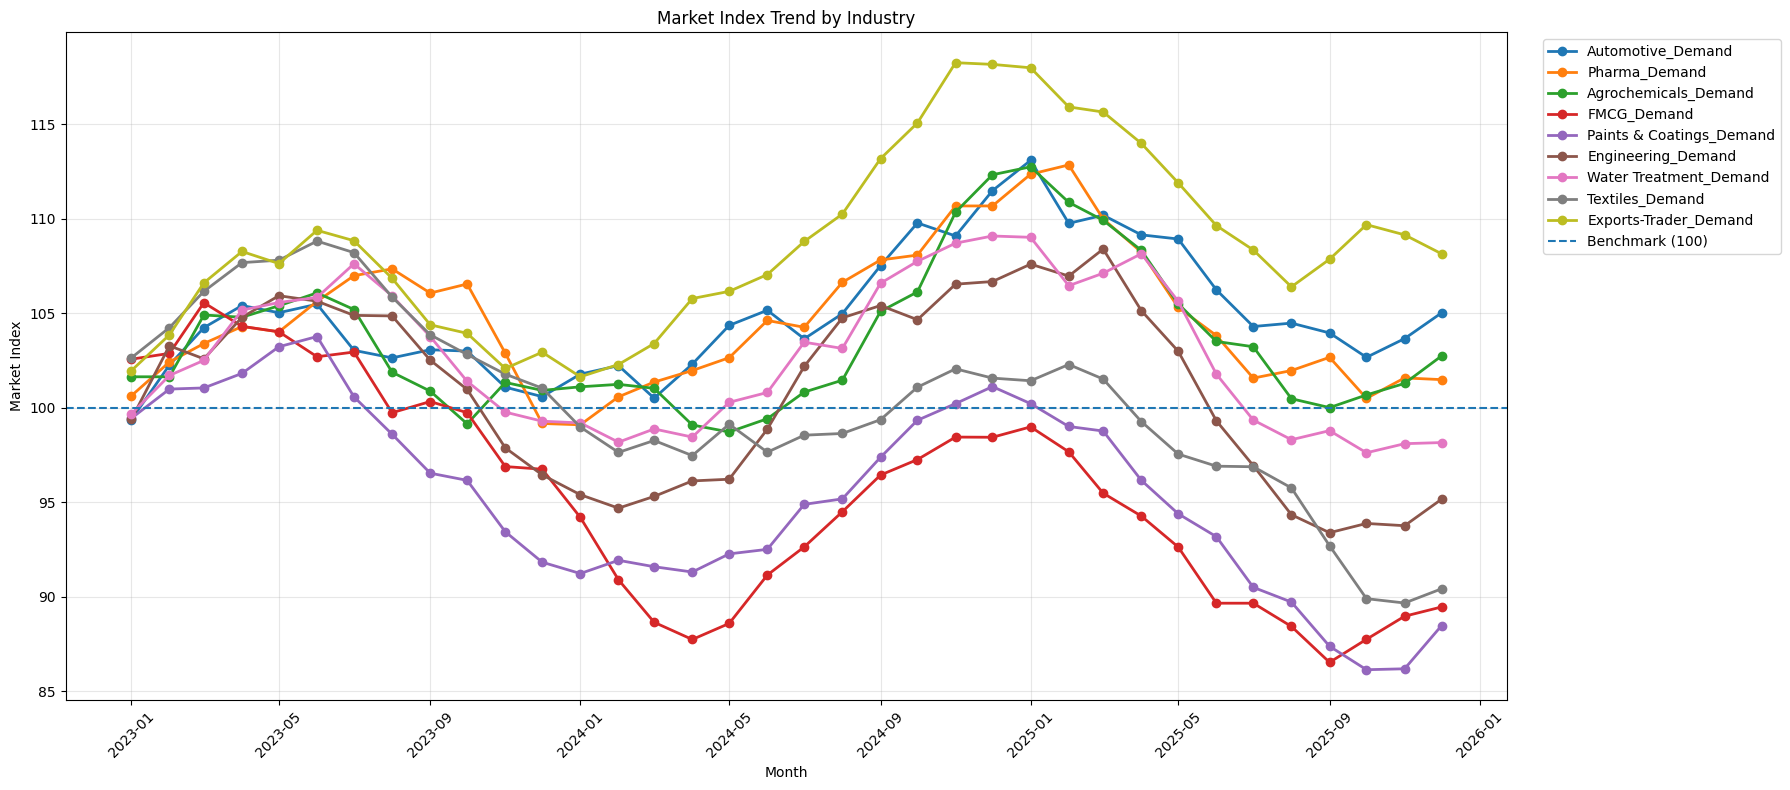

In [ ]:
df= Market_Index.copy()

index_cols = df.filter(regex="_Index$").columns

plt.figure(figsize=(18, 8))

for col in index_cols:
    plt.plot(
        df["Month"],
        df[col],
        marker="o",
        linewidth=2,
        label=col.replace("_Index", "")
    )

plt.axhline(
    y=100,
    linestyle="--",
    linewidth=1.5,
    label="Benchmark (100)"
)

plt.xlabel("Month")
plt.ylabel("Market Index")
plt.title("Market Index Trend by Industry")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
Market_Index_cols = [
    "Automotive_Demand_Index",
    "Pharma_Demand_Index",
    "Agrochemicals_Demand_Index",
    "FMCG_Demand_Index",
    "Paints & Coatings_Demand_Index",
    "Engineering_Demand_Index",
    "Water Treatment_Demand_Index",
    "Textiles_Demand_Index",
    "Exports-Trader_Demand_Index"
]

Market_Index_pivot = (
    Market_Index
    .assign(Month=pd.to_datetime(Market_Index["Month"]))
    .set_index("Month")[Market_Index_cols]
    .T
)

Market_Index_pivot.index = (
    Market_Index_pivot.index
    .str.replace("_Demand_Index", "", regex=False)
)

Market_Index_pivot.index.name = "Industry"
Market_Index_pivot.columns.name = None

Market_Index_pivot.columns = [
    pd.to_datetime(col).strftime("%Y-%m-%d")
    for col in Market_Index_pivot.columns
]

Market_Index_pivot = Market_Index_pivot.reindex(
    sorted(
        Market_Index_pivot.columns,
        key=pd.to_datetime
    ),
    axis=1
)


def growth_pct(start, end):
    if pd.isna(start) or pd.isna(end) or start == 0:
        return np.nan

    return ((end - start) / abs(start)) * 100


def direction(x, threshold=3):
    if pd.isna(x):
        return "Unknown"

    if x > threshold:
        return "Growing"

    elif x < -threshold:
        return "Declining"

    else:
        return "Stable"


def calculate_market_trajectory(row):
    values = row.values.astype(float)
    values = values[~np.isnan(values)]

    if len(values) < 24:
        return pd.Series({
            "Initial_Index": np.nan,
            "Latest_Index": np.nan,
            "12M_Growth_Pct": np.nan,
            "6M_Growth_Pct": np.nan,
            "3M_Growth_Pct": np.nan,
            "12M_Direction": "Unknown",
            "6M_Direction": "Unknown",
            "3M_Direction": "Unknown",
            "Overall_Growth_Pct": np.nan,
            "Overall_Direction": "Unknown",
            "Benchmark_Deviation": np.nan,
            "Benchmark_Status": "Unknown",
            "Market_Trajectory": "Unknown"
        })

    growth_12m = growth_pct(
        values[-24:-12].mean(),
        values[-12:].mean()
    )

    growth_6m = growth_pct(
        values[-12:-6].mean(),
        values[-6:].mean()
    )

    growth_3m = growth_pct(
        values[-6:-3].mean(),
        values[-3:].mean()
    )

    overall_growth = growth_pct(
        values[0],
        values[-1]
    )

    dir_12m = direction(growth_12m)
    dir_6m = direction(growth_6m)
    dir_3m = direction(growth_3m)
    overall_dir = direction(overall_growth)

    if dir_12m == "Growing" and dir_3m == "Growing":
        trajectory = "Consistent Growth"

    elif dir_12m == "Declining" and dir_3m == "Declining":
        trajectory = "Consistent Decline"

    elif dir_12m == "Growing" and dir_3m == "Declining":
        trajectory = "Growth to Decline"

    elif dir_12m == "Declining" and dir_3m == "Growing":
        trajectory = "Decline to Recovery"

    elif dir_12m == "Growing" and dir_3m == "Stable":
        trajectory = "Growth to Stable"

    elif dir_12m == "Declining" and dir_3m == "Stable":
        trajectory = "Decline to Stable"

    elif dir_12m == "Stable" and dir_3m == "Growing":
        trajectory = "Stable to Growth"

    elif dir_12m == "Stable" and dir_3m == "Declining":
        trajectory = "Stable to Decline"

    else:
        trajectory = "Stable / Mixed"

    latest_index = values[-1]
    benchmark_deviation = latest_index - 100

    if latest_index > 100:
        benchmark_status = "Above Benchmark"

    elif latest_index < 100:
        benchmark_status = "Below Benchmark"

    else:
        benchmark_status = "At Benchmark"

    return pd.Series({
        # "Initial_Index": values[0],
        # "Latest_Index": latest_index,
        # "12M_Growth_Pct": growth_12m,
        # "6M_Growth_Pct": growth_6m,
        # "3M_Growth_Pct": growth_3m,
        "12M_Direction": dir_12m,
        # "6M_Direction": dir_6m,
        "3M_Direction": dir_3m,
        # "Overall_Growth_Pct": overall_growth,
        "Overall_Direction": overall_dir,
        # "Benchmark_Deviation": benchmark_deviation,
        # "Benchmark_Status": benchmark_status,
        "Market_Trajectory": trajectory
    })


Market_Index_Trajectory = (
    Market_Index_pivot
    .apply(calculate_market_trajectory, axis=1)
    .reset_index()
)

Market_Index_Trajectory


,Industry,12M_Direction,3M_Direction,Overall_Direction,Market_Trajectory
0,Automotive,Stable,Stable,Growing,Stable / Mixed
1,Pharma,Stable,Stable,Stable,Stable / Mixed
2,Agrochemicals,Stable,Stable,Stable,Stable / Mixed
3,FMCG,Stable,Stable,Declining,Stable / Mixed
4,Paints & Coatings,Stable,Stable,Declining,Stable / Mixed
5,Engineering,Stable,Stable,Declining,Stable / Mixed
6,Water Treatment,Stable,Stable,Stable,Stable / Mixed
7,Textiles,Declining,Declining,Declining,Consistent Decline
8,Exports-Trader,Stable,Stable,Growing,Stable / Mixed


#### Add Market Index features

In [ ]:
CSRQ_CSAT_PMT_Index = CSRQ_CSAT_PMT.merge(Market_Index_Trajectory,left_on='Industry_Segment',right_on='Industry',how='left')
print(CSRQ_CSAT_PMT_Index.shape)
CSRQ_CSAT_PMT_Index.sample()

(850, 28)


,Customer_ID,Industry_Segment,Customer_Type,Years_With_Company,Strategic_Account_Flag,Recent_3M_Net_Sales_Direction,Overall_Net_Sales_Direction,Net_Sales_Trajectory,Recent_3M_Revenue_Direction,Overall_Revenue_Direction,...,Most_Frequent_Complaint,Total_Instances,Invoices_Paid_On_or_Before_Due,Median_Days_Past_Due,On_Time_Payment_Ratio,Industry,12M_Direction,3M_Direction,Overall_Direction,Market_Trajectory
670,MKT_C100670,Water Treatment,Direct,1,0,Growing,Declining,Consistent Growth,Growing,Declining,...,Delivery - Medium,70,22,4.5,0.314286,Water Treatment,Stable,Stable,Stable,Stable / Mixed


### Scoring Framework

#### Opportunity

In [ ]:
df = CSRQ_CSAT_PMT_Index.copy()


# ============================================================
# 1. OPPORTUNITY SCORE
# ============================================================

# ------------------------------------------------------------
# A. Customer Growth / Trajectory - 30 points
# ------------------------------------------------------------

def growth_score(row):

    score = 0

    # Revenue trajectory
    if row["Revenue_Trajectory"] in ["Consistent Growth", "Growth to Recovery"]:
        score += 15
    elif row["Revenue_Trajectory"] in ["Stable to Growth", "Growth to Stable"]:
        score += 12
    elif row["Revenue_Trajectory"] == "Stable / Mixed":
        score += 8
    elif row["Revenue_Trajectory"] in ["Stable to Decline", "Decline to Stable"]:
        score += 5
    elif row["Revenue_Trajectory"] in ["Consistent Decline", "Growth to Decline"]:
        score += 2

    # Net Sales trajectory
    if row["Net_Sales_Trajectory"] in ["Consistent Growth", "Growth to Recovery"]:
        score += 15
    elif row["Net_Sales_Trajectory"] in ["Stable to Growth", "Growth to Stable"]:
        score += 12
    elif row["Net_Sales_Trajectory"] == "Stable / Mixed":
        score += 8
    elif row["Net_Sales_Trajectory"] in ["Stable to Decline", "Decline to Stable"]:
        score += 5
    elif row["Net_Sales_Trajectory"] in ["Consistent Decline", "Growth to Decline"]:
        score += 2

    return score


df["Growth_Opportunity_Score"] = df.apply(
    growth_score,
    axis=1
)


# ------------------------------------------------------------
# B. Quotation Opportunity - 30 points
# ------------------------------------------------------------

# Recent quotation activity
def quote_activity_score(x):

    if x >= 20:
        return 15
    elif x >= 10:
        return 12
    elif x >= 5:
        return 9
    elif x >= 2:
        return 5
    else:
        return 2


df["Quote_Activity_Score"] = (
    df["Recent_3M_Quotes"]
    .apply(quote_activity_score)
)


# Recent win rate
def win_rate_score(x):

    if x >= 0.75:
        return 15
    elif x >= 0.60:
        return 12
    elif x >= 0.45:
        return 9
    elif x >= 0.30:
        return 5
    else:
        return 2


df["Win_Rate_Opportunity_Score"] = (
    df["Recent_3M_Win_Ratio"]
    .apply(win_rate_score)
)


df["Quotation_Opportunity_Score"] = (
    df["Quote_Activity_Score"]
    + df["Win_Rate_Opportunity_Score"]
)


# ------------------------------------------------------------
# C. Industry / Market Opportunity - 20 points
# ------------------------------------------------------------

def market_score(row):

    score = 0

    # Recent industry direction
    if row["3M_Direction"] == "Growing":
        score += 10
    elif row["3M_Direction"] == "Stable":
        score += 6
    elif row["3M_Direction"] == "Declining":
        score += 2

    # Overall industry direction
    if row["Overall_Direction"] == "Growing":
        score += 10
    elif row["Overall_Direction"] == "Stable":
        score += 6
    elif row["Overall_Direction"] == "Declining":
        score += 2

    return score


df["Market_Opportunity_Score"] = df.apply(
    market_score,
    axis=1
)


# ------------------------------------------------------------
# D. Strategic / Account Characteristics - 20 points
# ------------------------------------------------------------

def account_score(row):

    score = 0

    # Strategic account
    if row["Strategic_Account_Flag"] == 1:
        score += 10

    # Customer tenure
    if row["Years_With_Company"] >= 10:
        score += 10
    elif row["Years_With_Company"] >= 5:
        score += 8
    elif row["Years_With_Company"] >= 2:
        score += 5
    else:
        score += 2

    return score


df["Account_Opportunity_Score"] = df.apply(
    account_score,
    axis=1
)


# ------------------------------------------------------------
# FINAL OPPORTUNITY SCORE
# ------------------------------------------------------------

df["Opportunity_Score"] = (
    df["Growth_Opportunity_Score"]
    + df["Quotation_Opportunity_Score"]
    + df["Market_Opportunity_Score"]
    + df["Account_Opportunity_Score"]
)

#### Risk

In [ ]:
# ============================================================
# 2. RISK SCORE
# ============================================================


# ------------------------------------------------------------
# A. Complaint Risk - 40 points
# ------------------------------------------------------------

# Total complaints
def complaint_count_risk(x):

    if x >= 20:
        return 15
    elif x >= 10:
        return 12
    elif x >= 5:
        return 8
    elif x >= 2:
        return 4
    else:
        return 0


df["Complaint_Count_Risk"] = (
    df["Total_Complaints"]
    .apply(complaint_count_risk)
)


# Recent complaints
def recent_complaint_risk(x):

    if x >= 8:
        return 15
    elif x >= 5:
        return 12
    elif x >= 3:
        return 8
    elif x >= 1:
        return 4
    else:
        return 0


df["Recent_Complaint_Risk"] = (
    df["Recent_3M_Complaints"]
    .apply(recent_complaint_risk)
)


# Resolution time
def resolution_risk(x):

    if x >= 15:
        return 10
    elif x >= 10:
        return 8
    elif x >= 5:
        return 5
    elif x > 0:
        return 2
    else:
        return 0


df["Resolution_Time_Risk"] = (
    df["Median_Resolution_Days"]
    .apply(resolution_risk)
)


df["Complaint_Risk_Score"] = (
    df["Complaint_Count_Risk"]
    + df["Recent_Complaint_Risk"]
    + df["Resolution_Time_Risk"]
)


# ------------------------------------------------------------
# B. Payment Risk - 40 points
# ------------------------------------------------------------

# Late payment ratio
def late_payment_risk(x):

    if x >= 0.50:
        return 25
    elif x >= 0.30:
        return 20
    elif x >= 0.15:
        return 15
    elif x >= 0.05:
        return 8
    else:
        return 0


df["Late_Payment_Risk"] = (
    (1 - df["On_Time_Payment_Ratio"])
    .apply(late_payment_risk)
)


# Median days past due
def payment_delay_risk(x):

    if x >= 30:
        return 15
    elif x >= 15:
        return 12
    elif x >= 7:
        return 8
    elif x > 0:
        return 4
    else:
        return 0


df["Payment_Delay_Risk"] = (
    df["Median_Days_Past_Due"]
    .apply(payment_delay_risk)
)


df["Payment_Risk_Score"] = (
    df["Late_Payment_Risk"]
    + df["Payment_Delay_Risk"]
)


# ------------------------------------------------------------
# C. Customer Trajectory Risk - 20 points
# ------------------------------------------------------------

def trajectory_risk(row):

    score = 0

    # Revenue trajectory
    if row["Revenue_Trajectory"] in [
        "Consistent Decline",
        "Growth to Decline"
    ]:
        score += 10

    elif row["Revenue_Trajectory"] in [
        "Stable to Decline",
        "Decline to Stable"
    ]:
        score += 6

    # Net sales trajectory
    if row["Net_Sales_Trajectory"] in [
        "Consistent Decline",
        "Growth to Decline"
    ]:
        score += 10

    elif row["Net_Sales_Trajectory"] in [
        "Stable to Decline",
        "Decline to Stable"
    ]:
        score += 6

    return score


df["Trajectory_Risk_Score"] = df.apply(
    trajectory_risk,
    axis=1
)


# ------------------------------------------------------------
# FINAL RISK SCORE
# ------------------------------------------------------------

df["Risk_Score"] = (
    df["Complaint_Risk_Score"]
    + df["Payment_Risk_Score"]
    + df["Trajectory_Risk_Score"]
)

In [ ]:
def priority_segment(row):

    opportunity = row["Opportunity_Score"]
    risk = row["Risk_Score"]

    if opportunity >= 70 and risk < 30:
        return "Strategic Priority"

    elif opportunity >= 70 and risk >= 30:
        return "High Opportunity - High Risk"

    elif opportunity >= 50 and risk < 30:
        return "Growth Opportunity"

    elif opportunity >= 50 and risk >= 30:
        return "Selective Opportunity"

    elif opportunity < 50 and risk < 30:
        return "Develop / Monitor"

    else:
        return "Low Priority"


df["Sales_Priority"] = df.apply(
    priority_segment,
    axis=1
)

In [ ]:
df['Sales_Priority'].value_counts()

,count
Sales_Priority,
Low Priority,575
Selective Opportunity,247
High Opportunity - High Risk,27
Growth Opportunity,1


### Product Recommendation Framework

In [ ]:
Sales_Transactions.sample()

,Month,Customer_ID,Product_Family,Quantity_MT,Net_Price_INR_per_MT,Invoice_Value_INR_000,Discount_Pct,Contribution_Margin_Pct,Contribution_INR_000
664,2025-02-01,MKT_C100009,Chlorinated Solvent,31.6,70251.37,2220.17,4.34,24.44,542.71


In [ ]:
df=  Sales_Transactions.copy()
# Example:
# df columns = Month, Customer_ID, Product_Family, Quantity_MT

customer_product = (
    df.groupby(['Customer_ID', 'Product_Family'])['Quantity_MT']
      .sum()
      .unstack(fill_value=0)
)

purchase_matrix = (customer_product > 0).astype(int)

from sklearn.metrics.pairwise import cosine_similarity

product_similarity = cosine_similarity(purchase_matrix.T)
pd.DataFrame(
    product_similarity,
    index=purchase_matrix.columns,
    columns=purchase_matrix.columns
)

Product_Family,Caustic,Chlorinated Solvent,Custom Grade,Industrial Salt,PVC Resin,Specialty Chemical
Product_Family,,,,,,
Caustic,1.000000,1.000000,1.000000,1.000000,1.000000,0.999412
Chlorinated Solvent,1.000000,1.000000,1.000000,1.000000,1.000000,0.999412
Custom Grade,1.000000,1.000000,1.000000,1.000000,1.000000,0.999412
Industrial Salt,1.000000,1.000000,1.000000,1.000000,1.000000,0.999412
PVC Resin,1.000000,1.000000,1.000000,1.000000,1.000000,0.999412
Specialty Chemical,0.999412,0.999412,0.999412,0.999412,0.999412,1.000000
